# Heart Disease Prediction Using Data Analytics and Machine Learning
**Author:** Sujata Samanta

---
This notebook builds a machine-learning pipeline to predict whether a patient has heart disease,
using the classic Cleveland Heart Disease dataset (`heart.csv`).

**Dataset columns**

| Column | Description |
| --- | --- |
| age | Age of the patient (years) |
| sex | Sex (1 = male, 0 = female) |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting ECG results (0–2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise relative to rest |
| slope | Slope of peak exercise ST segment (0–2) |
| ca | Number of major vessels coloured by fluoroscopy (0–4) |
| thal | Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect) |
| target | **Target variable** — 1 = Heart Disease, 0 = No Heart Disease |

# Importing Dependencies

In [137]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
%matplotlib inline

# Data Collection

In [138]:
# Loading data
heart_data = pd.read_csv('heart.csv')

# Exploratory Data Analysis (EDA)

In [139]:
# Printing the first 5 rows of the dataframe
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [140]:
# Number of rows and columns in the dataframe
heart_data.shape

(303, 14)

In [141]:
# Getting more information about the dataset
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [142]:
# Checking for missing values in each column
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [143]:
# Statistical summary of the dataset
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [144]:
# Distribution of target variable
heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

    1 ---> Heart Disease (Positive)
    0 ---> No Heart Disease (Healthy)

In [145]:
# Grouping the data based on the target variable
heart_data.groupby('target').mean(numeric_only=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


# Data Pre-Processing

# Separating the Features & Target

In [146]:
X = heart_data.drop(columns=['target'], axis=1)
Y = heart_data['target']

# Splitting the Data to Training Data & Test Data

In [147]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=2,
    stratify=Y
)
# Keep an unscaled copy of X_train for EDA (feature importance chart)
# so the analysis section never touches X_test or the full dataset.
X_train_raw = X_train.copy()

In [148]:
X.shape, X_train.shape, X_test.shape

((303, 13), (242, 13), (61, 13))

# Feature Selection

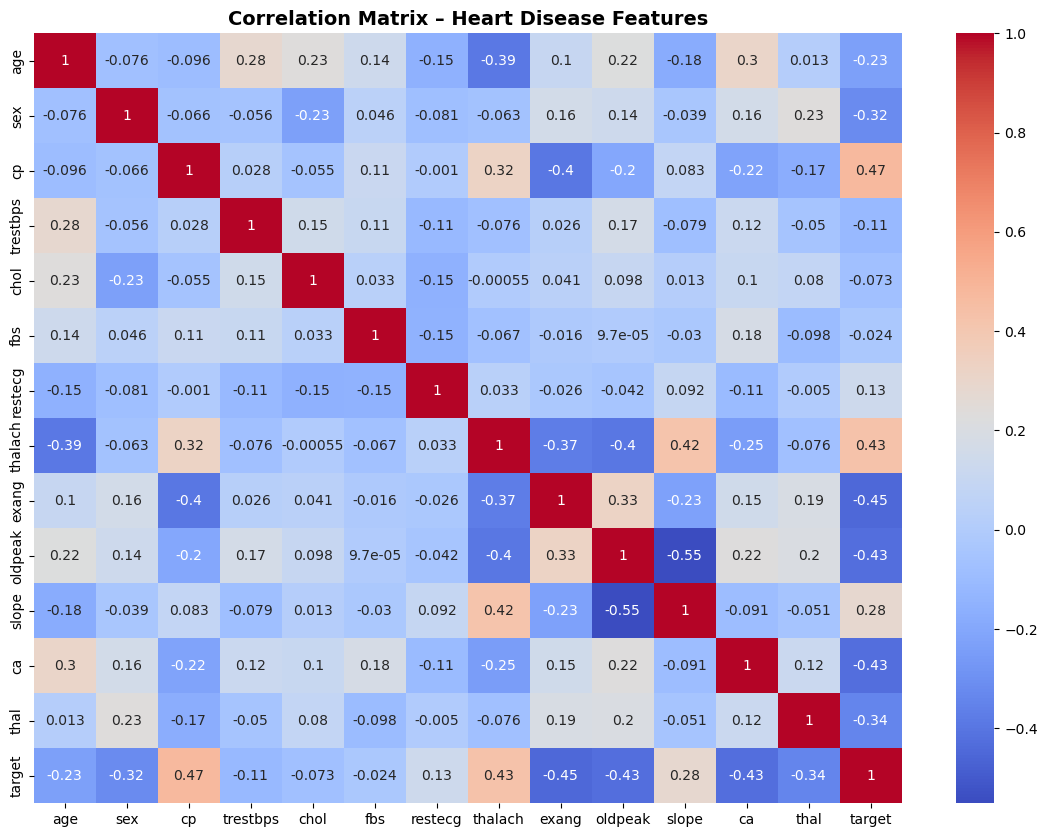

In [149]:
# Display correlation matrix as a heatmap
train_df = pd.concat([X_train, Y_train], axis=1)
corr_matrix = train_df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix – Heart Disease Features', fontsize=14, fontweight='bold')
plt.show()

In [150]:
# Select features whose absolute correlation with 'target' exceeds the threshold
corr_target = corr_matrix['target'].abs()
selected_features = corr_target[corr_target > 0.2].index
selected_features = selected_features.drop('target')
# Save a reference used by the EDA feature-importance chart (analysis section)
selected_features_raw = selected_features
print('Selected Features:', selected_features)

Selected Features: Index(['age', 'sex', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca',
       'thal'],
      dtype='object')


# Analysis

## 1. Heart Disease vs Healthy Patient Distribution

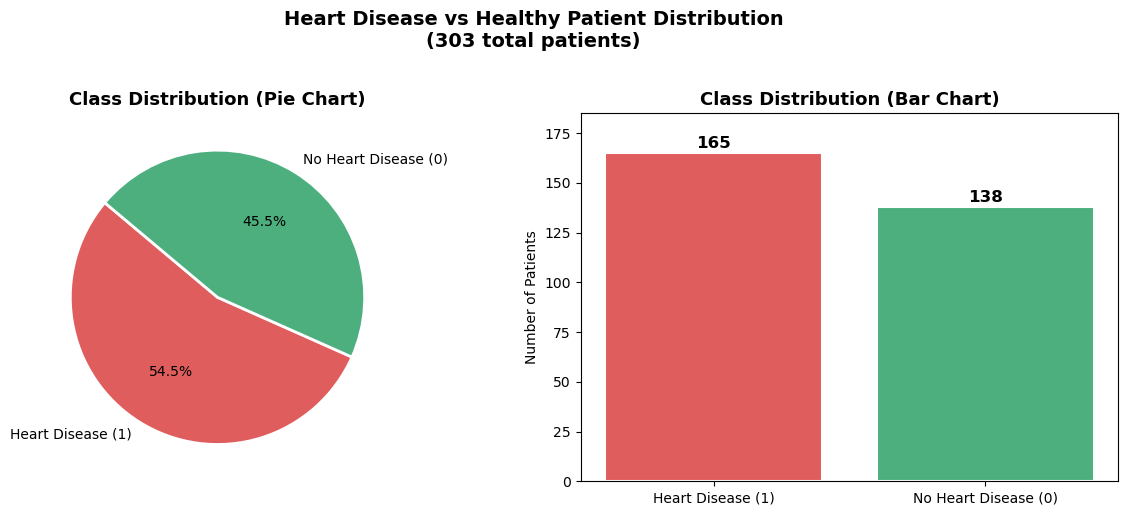

Heart Disease positive: 165 (54.5%)
No Heart Disease:       138 (45.5%)


In [151]:
# Heart Disease vs Healthy distribution
target_counts = heart_data['target'].value_counts()
labels = ['Heart Disease (1)', 'No Heart Disease (0)']
colors = ['#e05d5d', '#4caf7d']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(
    target_counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(labels, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, target_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Patients')
axes[1].set_ylim(0, max(target_counts.values) + 20)

plt.suptitle('Heart Disease vs Healthy Patient Distribution\n(303 total patients)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Heart Disease positive: {target_counts[1]} ({target_counts[1]/len(heart_data)*100:.1f}%)")
print(f"No Heart Disease:       {target_counts[0]} ({target_counts[0]/len(heart_data)*100:.1f}%)")

## 2. Age & Key Vital Feature Distributions by Class

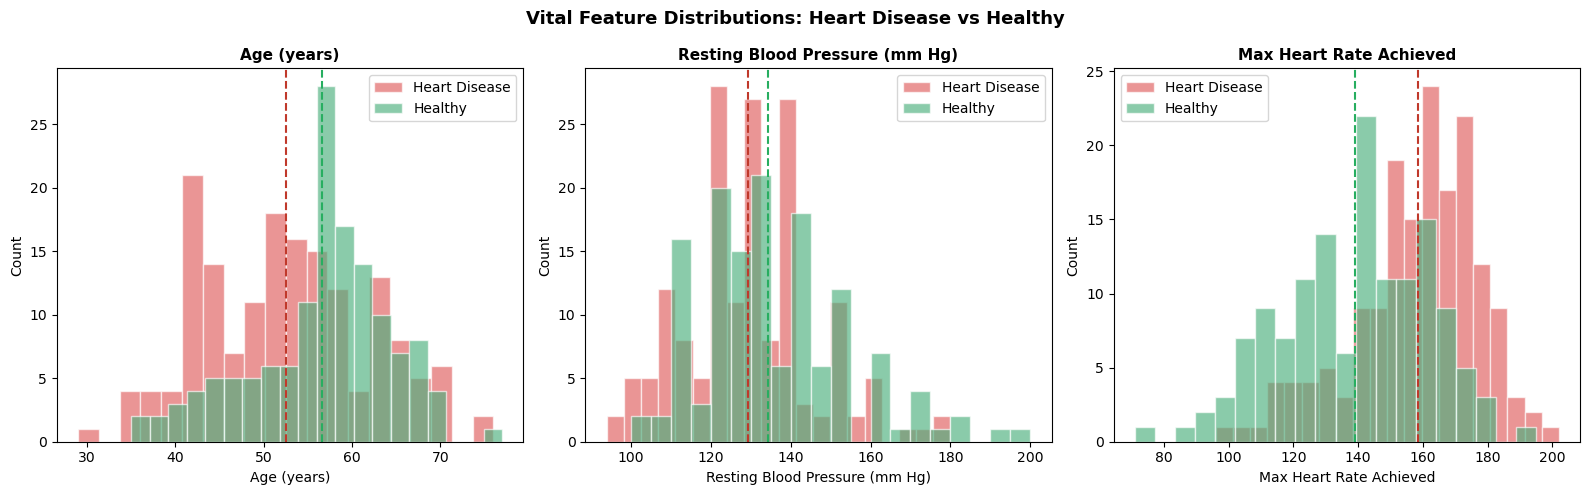

In [152]:
# Distribution of age, trestbps, thalach split by class
hd_data      = heart_data[heart_data['target'] == 1]   # heart disease patients
healthy_data = heart_data[heart_data['target'] == 0]   # healthy patients

vital_features = ['age', 'trestbps', 'thalach']
vital_labels   = ['Age (years)', 'Resting Blood Pressure (mm Hg)', 'Max Heart Rate Achieved']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (feat, label) in enumerate(zip(vital_features, vital_labels)):
    axes[i].hist(hd_data[feat],      bins=20, alpha=0.65, color='#e05d5d', label='Heart Disease', edgecolor='white')
    axes[i].hist(healthy_data[feat], bins=20, alpha=0.65, color='#4caf7d', label='Healthy',       edgecolor='white')
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Count')
    axes[i].legend()
    axes[i].axvline(hd_data[feat].mean(),      color='#c0392b', linestyle='--', linewidth=1.5)
    axes[i].axvline(healthy_data[feat].mean(), color='#27ae60', linestyle='--', linewidth=1.5)

plt.suptitle('Vital Feature Distributions: Heart Disease vs Healthy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Mean Comparison: Heart Disease vs Healthy Groups

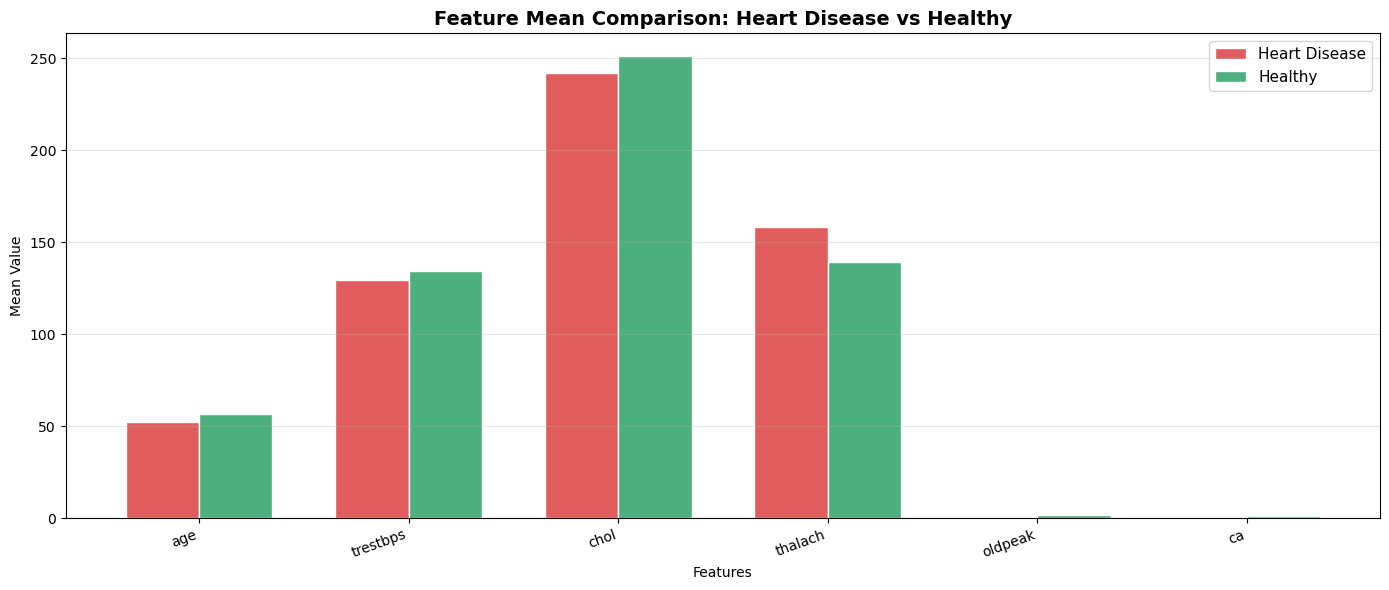

In [153]:
# Mean comparison of key features across groups
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

group_means    = heart_data.groupby('target')[key_features].mean()
hd_means       = group_means.loc[1]
healthy_means  = group_means.loc[0]

x     = range(len(key_features))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width/2 for i in x], hd_means.values,      width, label='Heart Disease', color='#e05d5d', edgecolor='white')
ax.bar([i + width/2 for i in x], healthy_means.values, width, label='Healthy',       color='#4caf7d', edgecolor='white')

ax.set_title('Feature Mean Comparison: Heart Disease vs Healthy', fontsize=14, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Mean Value')
ax.set_xticks(list(x))
ax.set_xticklabels(key_features, rotation=20, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Chest Pain Type & Sex Distribution

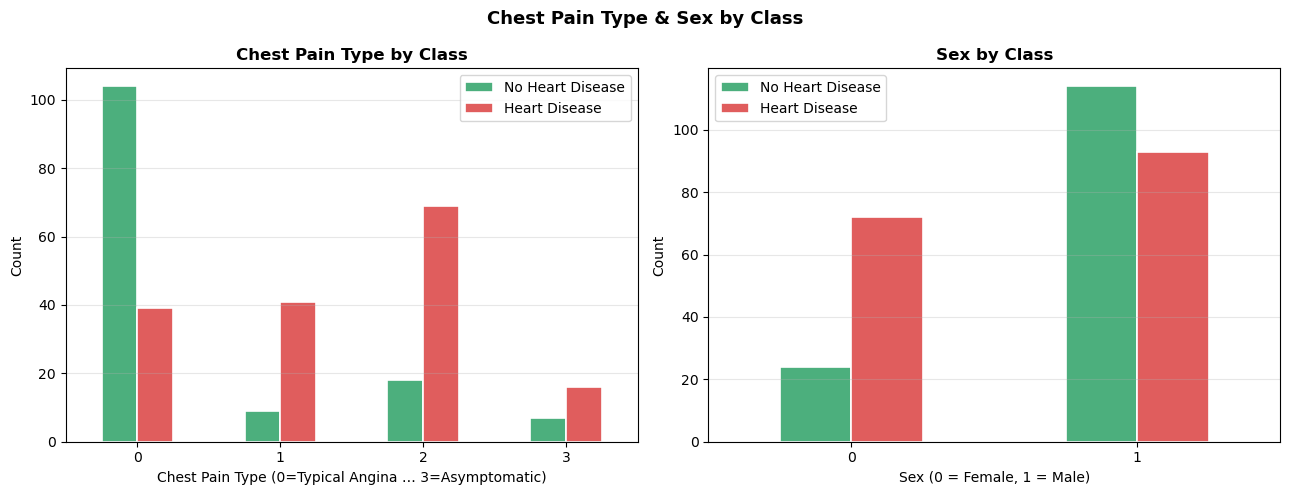

In [154]:
# Count plots for chest pain type and sex by target class
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chest pain type (cp)
cp_counts = heart_data.groupby(['cp', 'target']).size().unstack(fill_value=0)
cp_counts.plot(kind='bar', ax=axes[0], color=['#4caf7d', '#e05d5d'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Chest Pain Type by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Chest Pain Type (0=Typical Angina … 3=Asymptomatic)')
axes[0].set_ylabel('Count')
axes[0].legend(['No Heart Disease', 'Heart Disease'])
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Sex
sex_counts = heart_data.groupby(['sex', 'target']).size().unstack(fill_value=0)
sex_counts.plot(kind='bar', ax=axes[1], color=['#4caf7d', '#e05d5d'], edgecolor='white', linewidth=1.2)
axes[1].set_title('Sex by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sex (0 = Female, 1 = Male)')
axes[1].set_ylabel('Count')
axes[1].legend(['No Heart Disease', 'Heart Disease'])
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Chest Pain Type & Sex by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Oldpeak & Cholesterol Scatter Plot

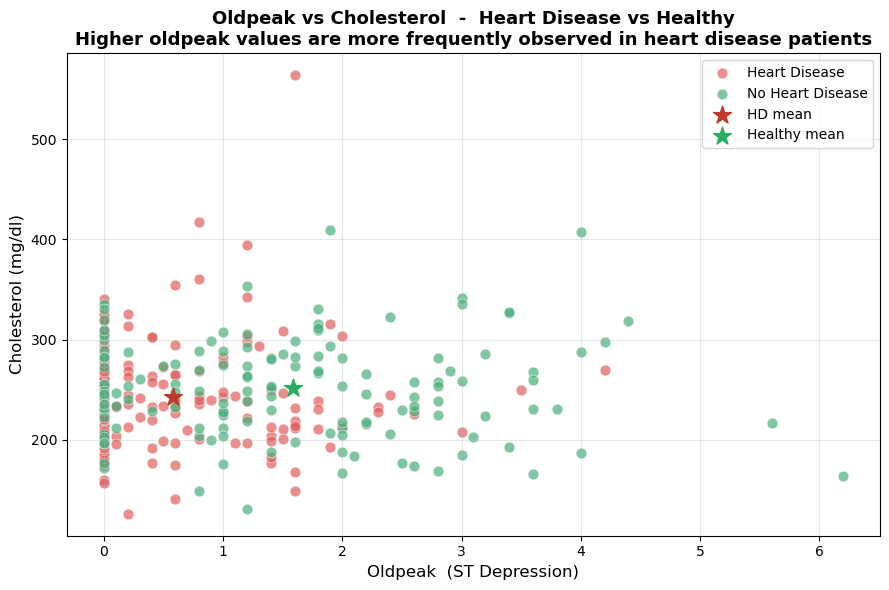

In [155]:
# Oldpeak vs Cholesterol scatter coloured by class
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(hd_data['oldpeak'],      hd_data['chol'],      c='#e05d5d', alpha=0.7, s=60,
           edgecolors='white', linewidths=0.5, label='Heart Disease')
ax.scatter(healthy_data['oldpeak'], healthy_data['chol'], c='#4caf7d', alpha=0.7, s=60,
           edgecolors='white', linewidths=0.5, label='No Heart Disease')

# Group mean markers
ax.scatter(hd_data['oldpeak'].mean(),      hd_data['chol'].mean(),      c='#c0392b', s=180,
           marker='*', zorder=5, label='HD mean')
ax.scatter(healthy_data['oldpeak'].mean(), healthy_data['chol'].mean(), c='#27ae60', s=180,
           marker='*', zorder=5, label='Healthy mean')

ax.set_xlabel('Oldpeak  (ST Depression)', fontsize=12)
ax.set_ylabel('Cholesterol (mg/dl)', fontsize=12)
ax.set_title('Oldpeak vs Cholesterol  -  Heart Disease vs Healthy\n'
             'Higher oldpeak values are more frequently observed in heart disease patients',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

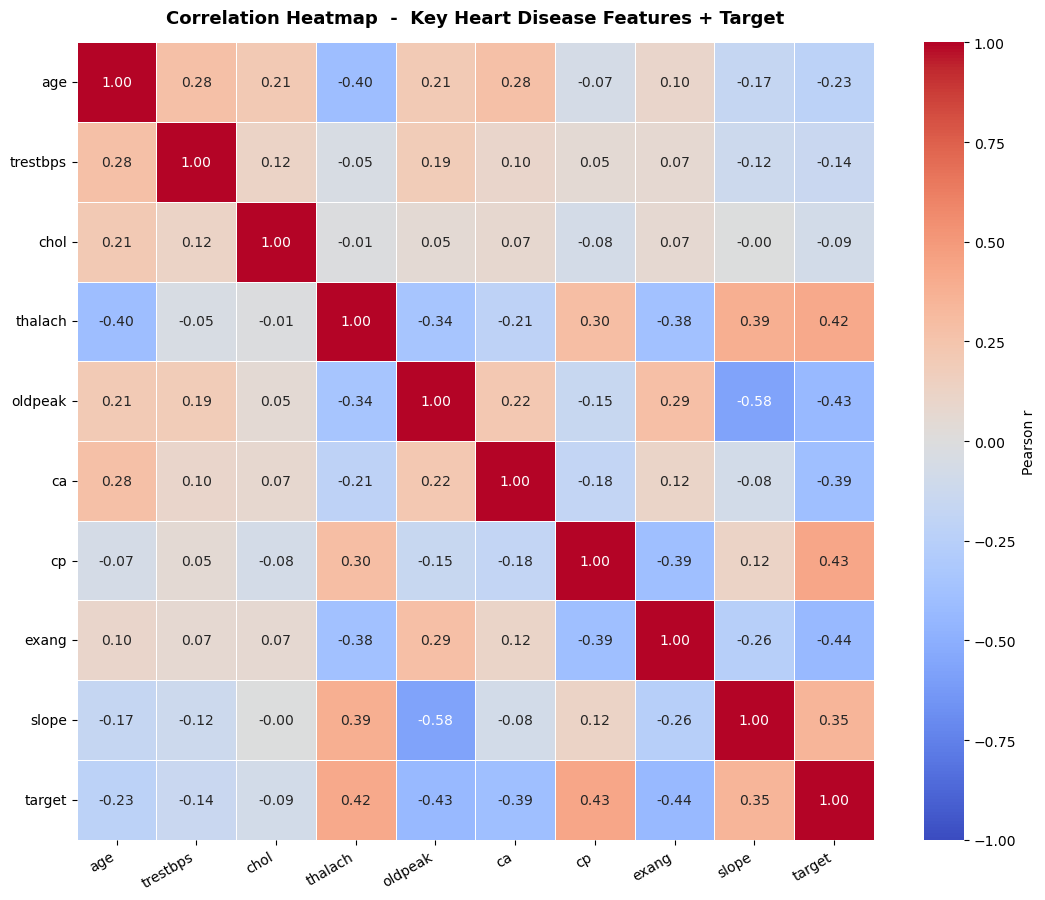

Top correlations with target (abs):
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
age         0.225439
trestbps    0.144931
chol        0.085239


In [156]:
# Correlation heatmap of all features including target
corr_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'cp', 'exang', 'slope', 'target']
corr_df   = heart_data[corr_cols].copy()
corr_mat  = corr_df.corr()

plt.figure(figsize=(11, 9))
heatmap = sns.heatmap(
    corr_mat,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Correlation Heatmap  -  Key Heart Disease Features + Target',
          fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('Top correlations with target (abs):')
print(corr_mat['target'].drop('target').abs().sort_values(ascending=False).to_string())

## 7. Feature Importance (Random Forest)

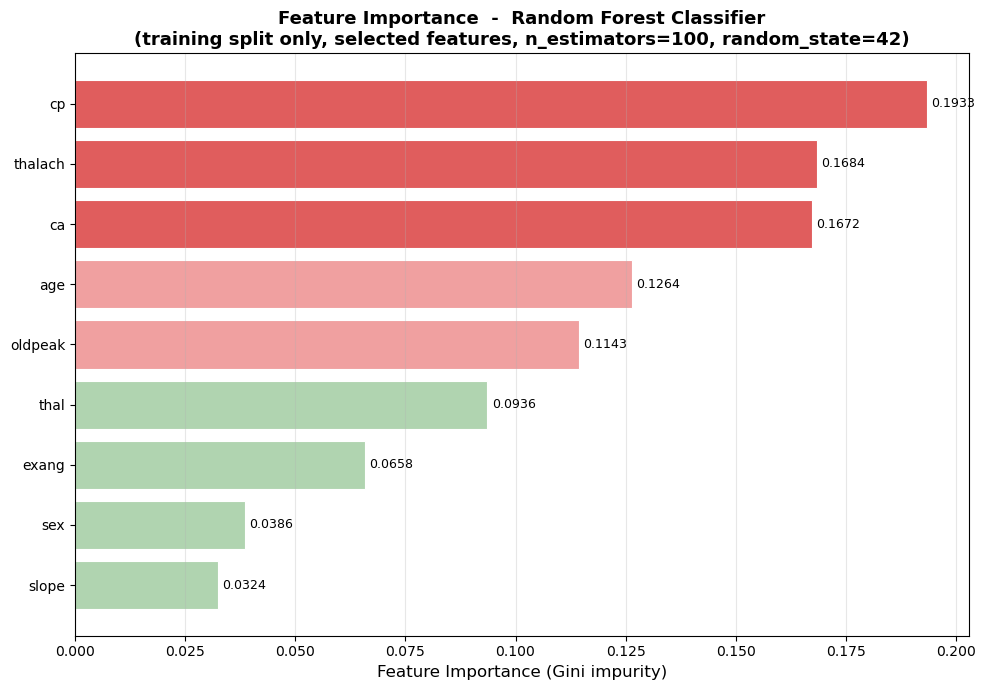


Top 5 most important features:
cp         0.193308
thalach    0.168402
ca         0.167213
age        0.126414
oldpeak    0.114330


In [157]:
# Feature importance using a Random Forest trained on TRAINING DATA ONLY
# NOTE: This cell is EDA/analysis only. The RF here uses the raw (unscaled)
# training split so that feature importances are not contaminated by test data.
# The model saved at the end of this notebook is trained separately below.
from sklearn.ensemble import RandomForestClassifier as RFC

analysis_data   = X_train_raw[selected_features_raw]  # raw (unscaled) train features
analysis_labels = Y_train

rf_analysis = RFC(n_estimators=100, random_state=42)
rf_analysis.fit(analysis_data, analysis_labels)

importances = pd.Series(rf_analysis.feature_importances_, index=analysis_data.columns)
importances_sorted = importances.sort_values(ascending=True)

colors_imp = ['#e05d5d' if v >= importances.quantile(0.75) else
              '#f0a0a0' if v >= importances.median() else
              '#b0d4b0' for v in importances_sorted.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importances_sorted.index, importances_sorted.values,
               color=colors_imp, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, importances_sorted.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini impurity)', fontsize=12)
ax.set_title('Feature Importance  -  Random Forest Classifier\n'
             '(training split only, selected features, n_estimators=100, random_state=42)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head(5).to_string())

In [158]:
# Apply feature selection: keep only features identified from training correlations
# This slice is applied once here on the raw (unscaled) DataFrames.
# The scaler is now embedded inside each Pipeline so CV folds never leak.
X_train = X_train[selected_features]
X_test  = X_test[selected_features]
print('X_train shape after feature selection:', X_train.shape)
print('X_test  shape after feature selection:', X_test.shape)

X_train shape after feature selection: (242, 9)
X_test  shape after feature selection: (61, 9)


## Data Standardization
**`StandardScaler` is embedded inside every Pipeline** (CV, GridSearch, and final models).
It is always fitted on the training fold only and never sees held-out data,
preventing any leakage of scaling statistics into evaluation.

# Model Selection

## Comparing Models with Default Hyperparameters using Pipeline + Cross-Validation
Each Pipeline bundles `StandardScaler + Classifier` so the scaler is re-fitted
on each training fold and never sees the validation fold.

In [159]:
# Build Pipelines: scaler is re-fitted on every CV training fold (no leakage)
pipelines = {
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', SVC(kernel='linear'))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=0))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
}

# StratifiedKFold preserves the class ratio in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CV on raw (unscaled) X_train -- scaler is re-fitted inside each fold
for name, pipe in pipelines.items():
    cv_scores = cross_val_score(pipe, X_train, Y_train, cv=skf, scoring='accuracy')
    mean_acc  = round(cv_scores.mean() * 100, 2)
    std_acc   = round(cv_scores.std()  * 100, 2)
    print(f'CV accuracies for {name}: {cv_scores}')
    print(f'Mean CV accuracy for {name}: {mean_acc} % (+/- {std_acc} %)')
    print('-' * 65)

CV accuracies for SVM: [0.83673469 0.85714286 0.83333333 0.85416667 0.79166667]
Mean CV accuracy for SVM: 83.46 % (+/- 2.34 %)
-----------------------------------------------------------------
CV accuracies for Random Forest: [0.81632653 0.87755102 0.77083333 0.83333333 0.79166667]
Mean CV accuracy for Random Forest: 81.79 % (+/- 3.66 %)
-----------------------------------------------------------------
CV accuracies for Logistic Regression: [0.83673469 0.81632653 0.83333333 0.85416667 0.77083333]
Mean CV accuracy for Logistic Regression: 82.23 % (+/- 2.84 %)
-----------------------------------------------------------------


## Inference (Default Hyperparameters)
With default hyperparameters **SVM** achieves the highest mean CV accuracy (**83.46 %**),
followed by Logistic Regression (82.23 %) and Random Forest (81.79 %).
We proceed to tune all three with GridSearchCV to find the best configuration for each.

## Hyperparameter Tuning with GridSearchCV (Pipeline-based)
Parameters are prefixed with `classifier__` to target the classifier step inside the Pipeline.

In [160]:
# Hyperparameter grids  -- keys use classifier__ prefix for Pipeline compatibility
param_grids = {
    'SVM': {
        'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'classifier__gamma':  [0.1, 0.01, 'scale'],
        'classifier__C':      [1, 5, 10, 20],
    },
    'Random Forest': {
        'classifier__n_estimators': [10, 20, 50, 100],
    },
    'Logistic Regression': {
        'classifier__C': [1, 5, 10, 20],
    },
}

In [161]:
# Run GridSearchCV for each model inside its Pipeline
# StratifiedKFold keeps the class balance in every search fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_results       = []
best_estimators  = {}   # stores gs.best_estimator_ for each model name

for name, pipe in pipelines.items():
    gs = GridSearchCV(pipe, param_grids[name], cv=skf, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, Y_train)   # raw X_train -- scaler handled inside Pipeline
    best_estimators[name] = gs.best_estimator_   # complete fitted Pipeline
    gs_results.append({
        'Model':         name,
        'Best CV Score': round(gs.best_score_ * 100, 2),
        'Best Params':   gs.best_params_,
    })
    print(f'{name}: best CV acc = {gs.best_score_*100:.2f}%  params = {gs.best_params_}')

gs_df = pd.DataFrame(gs_results)
print()
print(gs_df[['Model', 'Best CV Score']].to_string(index=False))

SVM: best CV acc = 84.29%  params = {'classifier__C': 10, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
Random Forest: best CV acc = 81.83%  params = {'classifier__n_estimators': 20}
Logistic Regression: best CV acc = 82.23%  params = {'classifier__C': 1}

              Model  Best CV Score
                SVM          84.29
      Random Forest          81.83
Logistic Regression          82.23


## Inference (GridSearchCV)
After hyperparameter tuning with `StratifiedKFold(n_splits=5)` and `random_state=42`:

| Model               | Best CV Accuracy | Best Parameters              |
| ------------------- | ---------------- | ---------------------------- |
| **SVM**             | **84.29 %**      | kernel=rbf, C=10, gamma=0.01 |
| Logistic Regression | 82.23 %          | C=1                          |
| Random Forest       | 81.83 %          | n_estimators=20              |

**SVM (RBF kernel, C=10, gamma=0.01)** achieves the highest cross-validated accuracy (84.29 %).
Each model is retrieved via `best_estimators[name]` — a complete fitted Pipeline (scaler + classifier) —
and evaluated on the held-out test set below to make the final deployment choice.

# Model Training

## SVM (Support Vector Machine)
Best GridSearch params: `kernel=rbf, C=10, gamma=0.01`

In [162]:
# Use the best Pipeline directly from GridSearchCV — no manual re-creation needed
svm_model = best_estimators['SVM']
svm_model   # already fitted; contains StandardScaler + SVC(rbf, C=10, gamma=0.01)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,10
,kernel,'rbf'
,degree,3
,gamma,0.01


In [163]:
# Pipeline handles its own scaling — pass raw (unscaled) X_test
Y_pred_svm = svm_model.predict(X_test)

print('=== SVM Results ===')
print('Test Accuracy :', round(accuracy_score(Y_test, Y_pred_svm) * 100, 2), '%')
print('Precision     :', round(precision_score(Y_test, Y_pred_svm) * 100, 2), '%')
print('Recall        :', round(recall_score(Y_test, Y_pred_svm) * 100, 2), '%')
print('F1 Score      :', round(f1_score(Y_test, Y_pred_svm) * 100, 2), '%')
print('Confusion Matrix:\n', confusion_matrix(Y_test, Y_pred_svm))
print()
print(classification_report(Y_test, Y_pred_svm))

=== SVM Results ===
Test Accuracy : 80.33 %
Precision     : 80.0 %
Recall        : 84.85 %
F1 Score      : 82.35 %
Confusion Matrix:
 [[21  7]
 [ 5 28]]

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



## Random Forest
Best GridSearch params: `n_estimators=20`

In [164]:
# Use the best Pipeline directly from GridSearchCV
# Note: the Pipeline still contains StandardScaler, but tree-based models
# are invariant to monotone feature scaling so results are equivalent.
random_forest_model = best_estimators['Random Forest']
random_forest_model   # already fitted; contains StandardScaler + RandomForest(n_estimators=20)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [165]:
# Pipeline handles preprocessing — pass raw (unscaled) X_test
Y_pred_rf = random_forest_model.predict(X_test)

print('=== Random Forest Results ===')
print('Test Accuracy :', round(accuracy_score(Y_test, Y_pred_rf) * 100, 2), '%')
print('Precision     :', round(precision_score(Y_test, Y_pred_rf) * 100, 2), '%')
print('Recall        :', round(recall_score(Y_test, Y_pred_rf) * 100, 2), '%')
print('F1 Score      :', round(f1_score(Y_test, Y_pred_rf) * 100, 2), '%')
print('Confusion Matrix:\n', confusion_matrix(Y_test, Y_pred_rf))
print()
print(classification_report(Y_test, Y_pred_rf))

=== Random Forest Results ===
Test Accuracy : 75.41 %
Precision     : 80.0 %
Recall        : 72.73 %
F1 Score      : 76.19 %
Confusion Matrix:
 [[22  6]
 [ 9 24]]

              precision    recall  f1-score   support

           0       0.71      0.79      0.75        28
           1       0.80      0.73      0.76        33

    accuracy                           0.75        61
   macro avg       0.75      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61



## Logistic Regression
Best GridSearch params: `C=1`

In [166]:
# Use the best Pipeline directly from GridSearchCV (C=1, as found by grid search)
logistic_regression_model = best_estimators['Logistic Regression']
logistic_regression_model   # already fitted; contains StandardScaler + LogisticRegression(C=1)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1


In [167]:
# Pipeline handles preprocessing — pass raw (unscaled) X_test
Y_pred_lr = logistic_regression_model.predict(X_test)

print('=== Logistic Regression Results ===')
print('Test Accuracy :', round(accuracy_score(Y_test, Y_pred_lr) * 100, 2), '%')
print('Precision     :', round(precision_score(Y_test, Y_pred_lr) * 100, 2), '%')
print('Recall        :', round(recall_score(Y_test, Y_pred_lr) * 100, 2), '%')
print('F1 Score      :', round(f1_score(Y_test, Y_pred_lr) * 100, 2), '%')
print('Confusion Matrix:\n', confusion_matrix(Y_test, Y_pred_lr))
print()
print(classification_report(Y_test, Y_pred_lr))

=== Logistic Regression Results ===
Test Accuracy : 78.69 %
Precision     : 81.25 %
Recall        : 78.79 %
F1 Score      : 80.0 %
Confusion Matrix:
 [[22  6]
 [ 7 26]]

              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



## Model Selection Conclusion

| Model                                      | Best CV Acc (GridSearch) | Test Accuracy | Notes                                          |
| ------------------------------------------ | ------------------------ | ------------- | ---------------------------------------------- |
| SVC (rbf, C=10, gamma=0.01)                | **84.29 %**              | **80.33 %**   | Highest CV accuracy **and** highest test accuracy — selected for deployment |
| Logistic Regression (C=1)                  | 82.23 %                  | 78.69 %       | Strong interpretability; good precision–recall |
| Random Forest (n_estimators=20)            | 81.83 %                  | 75.41 %       | Tree-based, invariant to scaling               |

**SVM (rbf, C=10, gamma=0.01) is saved as the deployment model** because:
- It achieved the **highest mean 5-fold cross-validation accuracy (84.29 %)**, the most reliable generalisation estimate.
- It also achieved the **highest test-set accuracy (80.33 %)** on the held-out split.
- The complete `Pipeline` (`StandardScaler → SVC`) is saved as a single `.pkl` file,
  making deployment safe and reproducible.

> **Academic note:** Cross-validation accuracy is generally a more reliable indicator
> of generalisation than a single held-out split because it averages over multiple folds.
> SVM leads both metrics here, making it the clear choice. Logistic Regression remains
> a strong alternative when interpretability (feature coefficients) is a priority.

## Building the Predictive System
The saved model is a single **end-to-end Pipeline** (`StandardScaler → SVC (rbf, C=10, gamma=0.01)`).
Pass raw (unscaled) feature values directly — the pipeline applies all preprocessing internally.

In [168]:
# -- Predictive System -------------------------------------------------------
# The pipeline (scaler + classifier) is self-contained:
# pass raw feature values in the order of selected_features.

def predict_heart_disease(input_values, pipeline=svm_model,
                           feature_names=list(selected_features)):
    """
    Predict whether a patient has heart disease.

    Parameters
    ----------
    input_values : list or tuple of floats, in the order of selected_features.
                   Raw (unscaled) values — the pipeline applies StandardScaler internally.

    Returns
    -------
    str - "Heart Disease" or "No Heart Disease"
    """
    df = pd.DataFrame([input_values], columns=feature_names)
    prediction = pipeline.predict(df)[0]
    return 'Heart Disease' if prediction == 1 else 'No Heart Disease'


# -- Example: first row of the test set -------------------------------------
sample_idx   = X_test.index[0]
sample_input = X_test.loc[sample_idx].tolist()   # already selected & unscaled
true_label   = 'Heart Disease' if Y_test.loc[sample_idx] == 1 else 'No Heart Disease'

result = predict_heart_disease(sample_input)
print('Input features  :', dict(zip(list(selected_features), sample_input)))
print('Predicted label :', result)
print('True label      :', true_label)

Input features  : {'age': 45.0, 'sex': 1.0, 'cp': 0.0, 'thalach': 147.0, 'exang': 1.0, 'oldpeak': 0.0, 'slope': 1.0, 'ca': 3.0, 'thal': 3.0}
Predicted label : No Heart Disease
True label      : No Heart Disease


# Saving the Trained Model
We save a **single Pipeline object** (`heart_disease_pipeline.pkl`) that bundles
`StandardScaler + SVC(rbf, C=10, gamma=0.01)` together.

A single file prevents the three-artifact mistake (wrong scaler, wrong feature order)
that can occur when `model.pkl`, `scaler.pkl`, and `selected_features.pkl` are
loaded separately during deployment.

**Loading at inference time:**
```python
import pickle, pandas as pd
pipeline = pickle.load(open('heart_disease_pipeline.pkl', 'rb'))
features = ['age', 'sex', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
df = pd.DataFrame([[45, 1, 0, 147, 1, 0.0, 1, 3, 3]], columns=features)
print(pipeline.predict(df))   # → [0] = No Heart Disease
```

In [169]:
import pickle

# Save a single end-to-end pipeline: StandardScaler + SVC(rbf, C=10, gamma=0.01)
# This is safer than saving model, scaler, and feature list separately —
# a single file guarantees consistent preprocessing at inference time.
pickle.dump(svm_model, open('heart_disease_pipeline.pkl', 'wb'))

print('Saved: heart_disease_pipeline.pkl')
print('Pipeline steps:', [name for name, _ in svm_model.steps])
print('Selected features:', list(selected_features))

Saved: heart_disease_pipeline.pkl
Pipeline steps: ['scaler', 'classifier']
Selected features: ['age', 'sex', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
